In [1]:
# kiểm tra GPU
import torch
print("1. CUDA Available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("2. Tên GPU:", torch.cuda.get_device_name(0))
else:
    print("2. Chưa nhận GPU (Đang là CPU)")

1. CUDA Available?: True
2. Tên GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. Clone repo mới nhất từ GitHub
!git clone https://github.com/nguyentranhuynhchi/SCAR.git
%cd /content/SCAR

fatal: destination path 'SCAR' already exists and is not an empty directory.
/content/SCAR


In [4]:
# 2. Cài đặt các gói phụ thuộc
!pip install -r requirements.txt
!pip install --upgrade gdown -q

In [5]:
import os

# Create the data directory inside SCAR
data_path = '/content/SCAR/data'
if not os.path.exists(data_path):
    os.makedirs(data_path)
    print(f"Successfully created: {data_path}")
else:
    print(f"Directory already exists: {data_path}")

Directory already exists: /content/SCAR/data


In [6]:
!cp -r /content/drive/MyDrive/CMR-MULTI/* /content/SCAR/data/



In [7]:
# 4. Quét dữ liệu và sinh danh sách train/val/test CSV
!python preprocessing/build_splits.py \
    --data-root data/LGE_MULTI \
    --output data/processed/splits

2026-08-25 03:40:45,843  INFO  Scanning data root: /content/SCAR/data/LGE_MULTI
2026-08-25 03:40:45,843  INFO  Found LGE task folders at: /content/SCAR/data/LGE_MULTI
2026-08-25 03:40:45,869  INFO    train       : 200 records
2026-08-25 03:40:45,870  INFO    validation  : 35 records
2026-08-25 03:40:45,871  INFO    test        : 65 records
2026-08-25 03:40:45,871  INFO  Splits CSVs saved to /content/SCAR/data/processed/splits
2026-08-25 03:40:45,876  INFO  Total: 300 records across 4 views.


In [8]:
# Chạy Cell 5 bằng lệnh này trên Colab:
!python preprocessing/process_and_save.py \
    --data-root data/LGE_MULTI \
    --splits-dir data/processed/splits \
    --output-dir data/processed/cache

03:40:47  INFO  Starting offline caching for 300 records...
Caching LGE Data: 100% 300/300 [00:32<00:00,  9.35it/s]
03:41:19  INFO  Successfully cached 300 LGE records into /content/SCAR/data/processed/cache


In [9]:
# 6. Kiểm tra kích thước và giá trị nhãn giải phẫu sau tiền xử lý
!python preprocessing/verify.py --data-root data/LGE_MULTI --n 3

  LGE_SAX_001.nii.gz: (200, 200, 10) (0.63086998462677, 0.5789160132408142, 10.00000286102295) mm  →  (192, 192, 16)  min=0.000  max=1.000
    label unique values: [0, 1, 2, 4]
  LGE_SAX_002.nii.gz: (200, 200, 10) (0.5496344566345215, 0.4922099709510803, 7.999987602233887) mm  →  (192, 192, 16)  min=0.000  max=1.000
    label unique values: [0, 1, 2, 4]
  LGE_SAX_003.nii.gz: (200, 200, 10) (0.574999988079071, 0.581250011920929, 7.999900817871094) mm  →  (192, 192, 16)  min=0.000  max=1.000
    label unique values: [0, 1, 2, 4]

Sanity check PASSED.


In [12]:
# 7. Huấn luyện mô hình (Mặc định 3D Residual U-Net, tự động lưu best_scar_dice.pt)
!python training/train.py \
    --config training/config/models/unet_3d.yaml \
    --run-id unet3d_lge_sax_exp01

03:41:23  INFO  Deterministic seed set to: 42
03:41:23  INFO  Using device: cuda
03:41:23  INFO  Dataset filtered: Train=40, Val=7 (View=SAX)
03:41:25  INFO  Starting training run 'unet3d_lge_sax_exp01' for 25 epochs...
03:41:46  INFO  Epoch   1/ 25 — train_loss=2.5597  val_loss=2.3342  dice_scar=0.0132  mean_dice=0.0622
03:42:13  INFO  Epoch   2/ 25 — train_loss=2.2079  val_loss=2.1394  dice_scar=0.0175  mean_dice=0.0872
03:42:42  INFO  Epoch   3/ 25 — train_loss=2.0507  val_loss=2.0249  dice_scar=0.0162  mean_dice=0.1147
03:43:05  INFO  Epoch   4/ 25 — train_loss=1.9503  val_loss=1.9440  dice_scar=0.0020  mean_dice=0.1528
03:43:30  INFO  Epoch   5/ 25 — train_loss=1.8723  val_loss=1.8849  dice_scar=0.0024  mean_dice=0.1685
03:43:52  INFO  Epoch   6/ 25 — train_loss=1.8153  val_loss=1.8384  dice_scar=0.0013  mean_dice=0.2043
03:44:14  INFO  Epoch   7/ 25 — train_loss=1.7697  val_loss=1.8053  dice_scar=0.0002  mean_dice=0.2265
03:44:37  INFO  Epoch   8/ 25 — train_loss=1.7289  val_loss

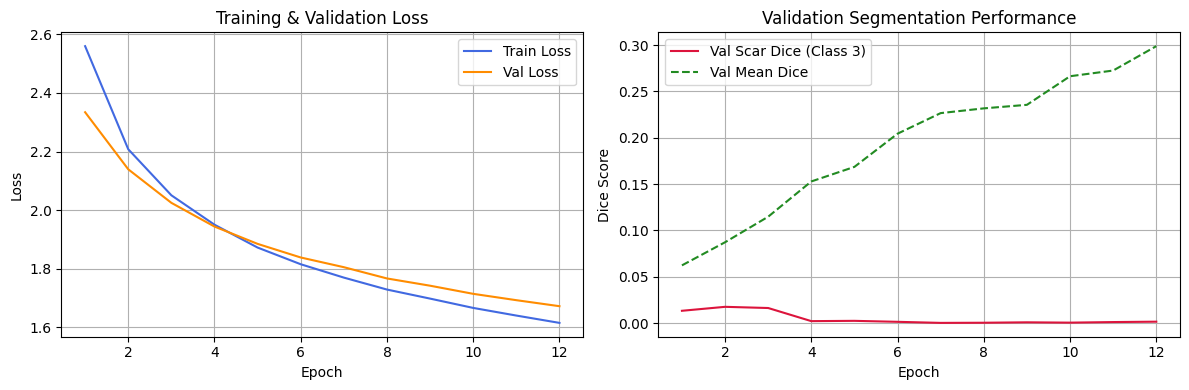

In [13]:
# 8. Trực quan hóa tiến trình huấn luyện
import json
import pandas as pd
import matplotlib.pyplot as plt

history_file = "outputs/runs/unet3d_lge_sax_exp01/logs/training_history.json"
with open(history_file, "r") as f:
    history = json.load(f)

df_hist = pd.DataFrame(history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(df_hist["epoch"], df_hist["train_loss"], label="Train Loss", color="royalblue")
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
if "dice_scar" in df_hist.columns:
    plt.plot(df_hist["epoch"], df_hist["dice_scar"], label="Val Scar Dice (Class 3)", color="crimson")
if "mean_dice" in df_hist.columns:
    plt.plot(df_hist["epoch"], df_hist["mean_dice"], label="Val Mean Dice", color="forestgreen", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Validation Segmentation Performance")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# 9. Đánh giá chi tiết (Dice, HD95 mm, Scar Volume mL, Scar Mass g)
!python training/evaluate.py \
    --config outputs/runs/unet3d_lge_sax_exp01/config_snapshot.yaml \
    --checkpoint outputs/runs/unet3d_lge_sax_exp01/checkpoints/best.pt \
    --split validation

2026-08-25 03:46:18,274  INFO  Loaded model from outputs/runs/unet3d_lge_sax_exp01/checkpoints/best.pt (epoch 2)
2026-08-25 03:46:18,279  INFO  Evaluating 7 records on 'validation' split for view 'SAX'...
2026-08-25 03:46:22,367  INFO  Evaluation complete! Results exported to:
  - /content/SCAR/outputs/runs/unet3d_lge_sax_exp01/evaluation/validation/per_subject_metrics.csv
  - /content/SCAR/outputs/runs/unet3d_lge_sax_exp01/evaluation/validation/per_class_summary.csv

--- Summary Performance ---
              metric      mean       std    median  count
      dice_lv_cavity  0.094420  0.021008  0.089980      7
       iou_lv_cavity  0.049659  0.011566  0.047109      7
   hd95_lv_cavity_mm 67.795243 17.806904 61.264726      7
         dice_lv_myo  0.079645  0.036148  0.072760      7
          iou_lv_myo  0.041793  0.019738  0.037754      7
      hd95_lv_myo_mm 65.093825 31.519228 56.146083      7
           dice_scar  0.020281  0.026271  0.007645      7
            iou_scar  0.010399  0.0

In [17]:
# 11. Huấn luyện mô hình 2D Res-UNet cho góc 2CH (Long-Axis)
!python training/train.py \
    --config training/config/models/unet_2d_2ch.yaml \
    --run-id unet2d_lge_2ch_exp01

03:47:13  INFO  Deterministic seed set to: 42
03:47:13  INFO  Using device: cuda
03:47:13  INFO  Dataset filtered: Train=40, Val=7 (View=2CH)
03:47:15  INFO  Starting training run 'unet2d_lge_2ch_exp01' for 25 epochs...
03:47:21  INFO  Epoch   1/ 25 — train_loss=2.0963  val_loss=2.2793  dice_scar=0.0000  mean_dice=0.0318
03:47:29  INFO  Epoch   2/ 25 — train_loss=1.8757  val_loss=2.2633  dice_scar=0.0000  mean_dice=0.0085
03:47:34  INFO  Epoch   3/ 25 — train_loss=1.7533  val_loss=2.2034  dice_scar=0.0952  mean_dice=0.0633
03:47:41  INFO  Epoch   4/ 25 — train_loss=1.6630  val_loss=2.1044  dice_scar=0.2857  mean_dice=0.1348
03:47:47  INFO  Epoch   5/ 25 — train_loss=1.5887  val_loss=1.9821  dice_scar=0.2857  mean_dice=0.1361
03:47:54  INFO  Epoch   6/ 25 — train_loss=1.5137  val_loss=1.8526  dice_scar=0.2385  mean_dice=0.1239
03:47:59  INFO  Epoch   7/ 25 — train_loss=1.4495  val_loss=1.7359  dice_scar=0.2857  mean_dice=0.2174
03:48:05  INFO  Epoch   8/ 25 — train_loss=1.3999  val_loss

In [18]:
# 12. Huấn luyện mô hình 2D Res-UNet cho góc 4CH (Long-Axis)
!python training/train.py \
    --config training/config/models/unet_2d_4ch.yaml \
    --run-id unet2d_lge_4ch_exp01

03:48:42  INFO  Deterministic seed set to: 42
03:48:42  INFO  Using device: cuda
03:48:42  INFO  Dataset filtered: Train=40, Val=7 (View=4CH)
03:48:43  INFO  Starting training run 'unet2d_lge_4ch_exp01' for 25 epochs...
03:48:49  INFO  Epoch   1/ 25 — train_loss=2.3474  val_loss=2.5804  dice_scar=0.2857  mean_dice=0.0789
03:48:56  INFO  Epoch   2/ 25 — train_loss=2.1308  val_loss=2.5664  dice_scar=0.2857  mean_dice=0.0789
03:49:01  INFO  Epoch   3/ 25 — train_loss=2.0009  val_loss=2.5042  dice_scar=0.2857  mean_dice=0.0860
03:49:07  INFO  Epoch   4/ 25 — train_loss=1.8975  val_loss=2.3930  dice_scar=0.2857  mean_dice=0.0985
03:49:12  INFO  Epoch   5/ 25 — train_loss=1.8132  val_loss=2.2505  dice_scar=0.2857  mean_dice=0.0986
03:49:18  INFO  Epoch   6/ 25 — train_loss=1.7315  val_loss=2.1026  dice_scar=0.2857  mean_dice=0.1006
03:49:23  INFO  Epoch   7/ 25 — train_loss=1.6651  val_loss=1.9636  dice_scar=0.2857  mean_dice=0.1292
03:49:29  INFO  Epoch   8/ 25 — train_loss=1.6095  val_loss

In [19]:
# 13. Huấn luyện mô hình 2D Res-UNet cho góc RAS
!python training/train.py \
    --config training/config/models/unet_2d_ras.yaml \
    --run-id unet2d_lge_ras_exp01

03:49:49  INFO  Deterministic seed set to: 42
03:49:49  INFO  Using device: cuda
03:49:49  INFO  Dataset filtered: Train=80, Val=14 (View=RAS)
03:49:51  INFO  Starting training run 'unet2d_lge_ras_exp01' for 25 epochs...
03:50:24  INFO  Epoch   1/ 25 — train_loss=1.3005  val_loss=1.4675  mean_dice=0.1628
03:50:56  INFO  Epoch   2/ 25 — train_loss=1.0697  val_loss=1.1363  mean_dice=0.2266
03:51:28  INFO  Epoch   3/ 25 — train_loss=0.9474  val_loss=1.0396  mean_dice=0.2460
03:52:00  INFO  Epoch   4/ 25 — train_loss=0.8535  val_loss=0.9434  mean_dice=0.4008
03:52:32  INFO  Epoch   5/ 25 — train_loss=0.7668  val_loss=0.8968  mean_dice=0.4562
03:53:05  INFO  Epoch   6/ 25 — train_loss=0.7231  val_loss=0.8507  mean_dice=0.5031
03:53:38  INFO  Epoch   7/ 25 — train_loss=0.6654  val_loss=0.8374  mean_dice=0.5312
03:54:10  INFO  Epoch   8/ 25 — train_loss=0.6226  val_loss=0.7778  mean_dice=0.5717
03:54:43  INFO  Epoch   9/ 25 — train_loss=0.5802  val_loss=0.7460  mean_dice=0.6024
03:55:15  INFO

In [20]:
# 14. Đánh giá toàn bộ 4 góc nhìn và tổng hợp kết quả (Paper-ready Benchmark)
import pandas as pd

experiments = {
    "SAX (3D)": "unet3d_lge_sax_exp01",
    "2CH (2D)": "unet2d_lge_2ch_exp01",
    "4CH (2D)": "unet2d_lge_4ch_exp01",
    "RAS (2D)": "unet2d_lge_ras_exp01",
}

# 1. Chạy evaluate cho từng góc
for view_name, run_id in experiments.items():
    print(f"\n>>> Đang đánh giá góc nhìn: {view_name} ({run_id})...")
    !python training/evaluate.py \
        --config outputs/runs/{run_id}/config_snapshot.yaml \
        --checkpoint outputs/runs/{run_id}/checkpoints/best.pt \
        --split validation

# 2. Tổng hợp kết quả thành 1 bảng duy nhất
summary_list = []
for view_name, run_id in experiments.items():
    csv_path = f"outputs/runs/{run_id}/evaluation/validation/per_class_summary.csv"
    try:
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            summary_list.append({
                "View": view_name,
                "Metric": row["metric"],
                "Mean": row["mean"],
                "STD": row["std"],
                "Median": row["median"]
            })
    except Exception as e:
        print(f" Chưa có kết quả cho {view_name}")

benchmark_df = pd.DataFrame(summary_list)

print("\n" + "="*70)
print(" BẢNG TỔNG HỢP KẾT QUẢ ĐA GÓC NHÌN (MULTI-VIEW BENCHMARK)")
print("="*70)
display(benchmark_df)

# Lưu bảng tổng hợp vào file CSV
benchmark_df.to_csv("outputs/multiview_final_benchmark.csv", index=False)


>>> Đang đánh giá góc nhìn: SAX (3D) (unet3d_lge_sax_exp01)...
2026-08-25 04:03:16,805  INFO  Loaded model from outputs/runs/unet3d_lge_sax_exp01/checkpoints/best.pt (epoch 2)
2026-08-25 04:03:16,809  INFO  Evaluating 7 records on 'validation' split for view 'SAX'...
2026-08-25 04:03:20,912  INFO  Evaluation complete! Results exported to:
  - /content/SCAR/outputs/runs/unet3d_lge_sax_exp01/evaluation/validation/per_subject_metrics.csv
  - /content/SCAR/outputs/runs/unet3d_lge_sax_exp01/evaluation/validation/per_class_summary.csv

--- Summary Performance ---
              metric      mean       std    median  count
      dice_lv_cavity  0.094420  0.021008  0.089980      7
       iou_lv_cavity  0.049659  0.011566  0.047109      7
   hd95_lv_cavity_mm 67.795243 17.806904 61.264726      7
         dice_lv_myo  0.079645  0.036148  0.072760      7
          iou_lv_myo  0.041793  0.019738  0.037754      7
      hd95_lv_myo_mm 65.093825 31.519228 56.146083      7
           dice_scar  0.02028

,View,Metric,Mean,STD,Median
0,SAX (3D),dice_lv_cavity,0.094420,0.021008,0.089980
1,SAX (3D),iou_lv_cavity,0.049659,0.011566,0.047109
2,SAX (3D),hd95_lv_cavity_mm,67.795243,17.806904,61.264726
3,SAX (3D),dice_lv_myo,0.079645,0.036148,0.072760
4,SAX (3D),iou_lv_myo,0.041793,0.019738,0.037754
5,SAX (3D),hd95_lv_myo_mm,65.093825,31.519228,56.146083
6,SAX (3D),dice_scar,0.020281,0.026271,0.007645
7,SAX (3D),iou_scar,0.010399,0.013564,0.003837
8,SAX (3D),hd95_scar_mm,76.503884,55.138932,51.059016
9,SAX (3D),dice_rv_cavity,0.204060,0.073471,0.213542


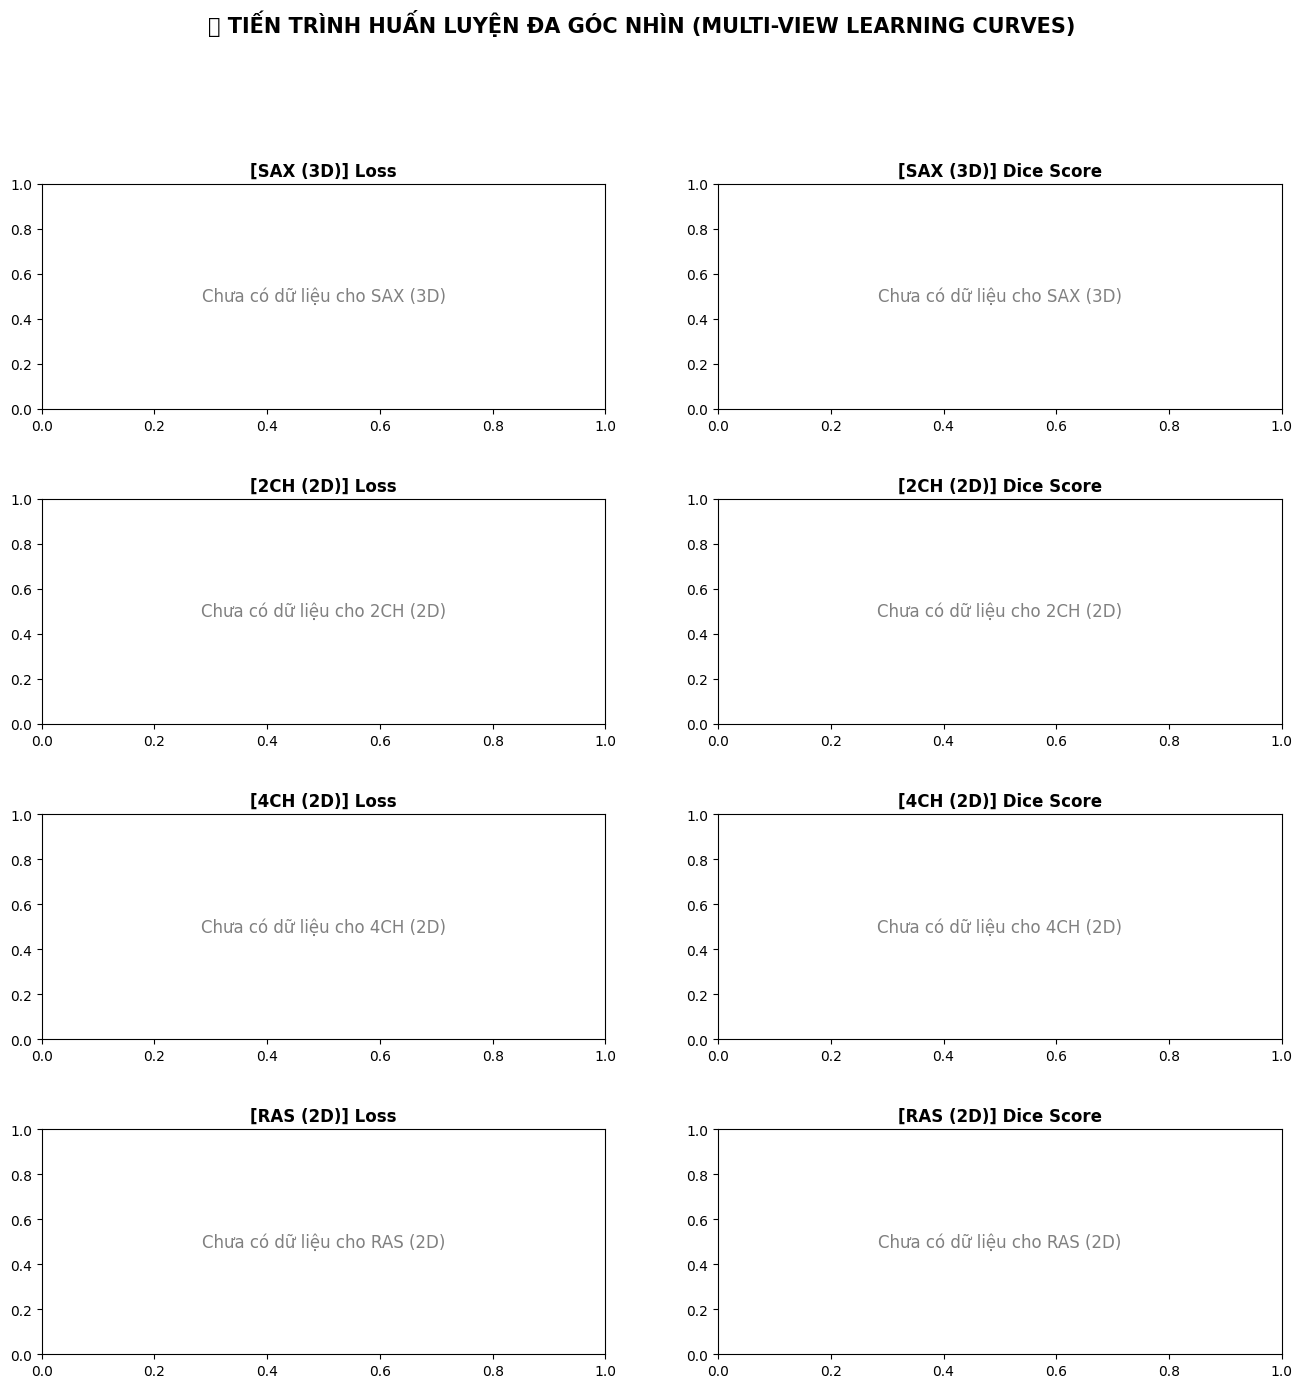

In [25]:
# 15. Vẽ đồ thị trực quan hóa tiến trình huấn luyện tổng thể các góc nhìn
import json
import matplotlib.pyplot as plt
from pathlib import Path

runs_info = [
    {"view": "SAX (3D)", "run_id": "unet3d_lge_sax_exp01", "has_scar": True},
    {"view": "2CH (2D)", "run_id": "unet2d_lge_2ch_exp01", "has_scar": True},
    {"view": "4CH (2D)", "run_id": "unet2d_lge_4ch_exp01", "has_scar": True},
    {"view": "RAS (2D)", "run_id": "unet2d_lge_ras_exp01", "has_scar": False},
]

fig, axes = plt.subplots(len(runs_info), 2, figsize=(16, 3.8 * len(runs_info)))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

for i, info in enumerate(runs_info):
    view_name = info["view"]
    run_id = info["run_id"]
    has_scar = info["has_scar"]

    history_file = Path(f"outputs/runs/{run_id}/training_history.json")
    ax_loss = axes[i, 0]
    ax_dice = axes[i, 1]

    if not history_file.exists():
        ax_loss.text(0.5, 0.5, f"Chưa có dữ liệu cho {view_name}", ha="center", va="center", fontsize=12, color="gray")
        ax_dice.text(0.5, 0.5, f"Chưa có dữ liệu cho {view_name}", ha="center", va="center", fontsize=12, color="gray")
        ax_loss.set_title(f"[{view_name}] Loss", fontweight="bold")
        ax_dice.set_title(f"[{view_name}] Dice Score", fontweight="bold")
        continue

    with open(history_file, "r", encoding="utf-8") as f:
        history = json.load(f)

    epochs = [entry["epoch"] for entry in history]
    train_loss = [entry["train_loss"] for entry in history]
    val_loss = [entry["val_loss"] for entry in history]
    mean_dice = [entry["mean_dice"] for entry in history]

    # 1. Đồ thị Loss
    ax_loss.plot(epochs, train_loss, label="Train Loss", color="#2b5c8f", lw=2)
    ax_loss.plot(epochs, val_loss, label="Val Loss", color="#e67e22", lw=2)
    ax_loss.set_title(f"[{view_name}] Training & Validation Loss", fontsize=12, fontweight="bold")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(loc="upper right")
    ax_loss.grid(True, linestyle="--", alpha=0.6)

    # 2. Đồ thị Dice Score
    if has_scar and len(history) > 0 and "dice_scar" in history[0]:
        scar_dice = [entry["dice_scar"] for entry in history]
        ax_dice.plot(epochs, scar_dice, label="Val Scar Dice (Class 3)", color="#d63031", lw=2)

    ax_dice.plot(epochs, mean_dice, label="Val Mean Dice", color="#27ae60", linestyle="--", lw=2)
    ax_dice.set_title(f"[{view_name}] Validation Segmentation Performance", fontsize=12, fontweight="bold")
    ax_dice.set_xlabel("Epoch")
    ax_dice.set_ylabel("Dice Score")
    ax_dice.legend(loc="upper left")
    ax_dice.grid(True, linestyle="--", alpha=0.6)

plt.suptitle(" TIẾN TRÌNH HUẤN LUYỆN ĐA GÓC NHÌN (MULTI-VIEW LEARNING CURVES)",
             fontsize=15, fontweight="bold", y=0.995)
plt.show()